In [1]:
import pandas as pd
import csv
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.stats import pearsonr, spearmanr
from disease import Disease
import networkx as nx

In [8]:
np.set_printoptions(precision=16, suppress=False)
pd.set_option('display.precision', 16)

In [2]:
filename = 'data/final_enr.csv'
columns = ['diseaseId', '#snp', '#border_snp', 'pval_tad', 'pval_border', 'pval_outside', 'is_cancer', 'window_size', 'filter']
df = pd.read_csv(filename, usecols=columns)
print(df.head)

<bound method NDFrame.head of              diseaseId  #snp  #border_snp  pval_tad  pval_border  \
0          EFO_0000094    22           13  0.000000     0.000000   
1          EFO_0000095   130           72  0.000000     0.000000   
2          EFO_0000096    13            6  0.000000     0.000000   
3          EFO_0000174     7            3  0.000000     0.000000   
4          EFO_0000178    37           16  0.000000     0.000000   
...                ...   ...          ...       ...          ...   
71741    Orphanet_1945    11            0       NaN          NaN   
71742  Orphanet_391311    15            5  0.950432     0.172214   
71743     Orphanet_654     7            3  0.969582     0.088117   
71744   Orphanet_93957     3            0       NaN          NaN   
71745   Orphanet_98974     7            2  0.730591     0.294210   

       pval_outside  is_cancer  window_size     filter  
0          1.000000      False            0   nofilter  
1          1.000000      False         

In [3]:
df = df[(df['#snp'] != 1) & (df['#border_snp'] != 1)]
df.shape

(52196, 9)

In [4]:
df = df[df['#border_snp'] != 0]
df.shape

(43950, 9)

In [5]:
df_cancers = pd.read_csv("data/cancerous_clustering.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical', 'name'])
df_cancers = df_cancers.rename(columns={'efoID': 'diseaseId'})
df_cancers.shape

(32, 5)

In [6]:
df_noncancers = pd.read_csv("data/noncancerous_clustering.csv", usecols=['efoID', 'z_score', 'pvalue', 'p_empirical', 'name'])
df_noncancers = df_noncancers.rename(columns={'efoID': 'diseaseId'})
df_noncancers.shape

(247, 5)

In [7]:
combined = pd.concat([df_cancers, df_noncancers])

In [8]:
combined.head()

,name,diseaseId,z_score,pvalue,p_empirical
0,basal cell carcinoma,EFO_0004193,4.690213,0.000031,0.001998
1,squamous cell carcinoma,EFO_0000707,3.968751,0.001300,0.009990
2,keratinocyte carcinoma,EFO_0010176,5.038859,0.004000,0.001998
3,cutaneous melanoma,EFO_0000389,15.667010,0.000000,0.000999
4,colorectal cancer,MONDO_0005575,0.216129,0.002900,0.401598


In [9]:
combined.shape

(279, 5)

In [49]:
def map_genes(row):
    try:
        d = Disease(row['name'], row['diseaseId'])
        genes = d.get_genes()
        return ",".join(genes) if genes else ""
    except Exception as e:
        print(f"Problem with {row['diseaseId']}: {e}")
        return ""


combined['mapped-genes'] = combined.apply(map_genes, axis=1)
combined.to_csv('data/combined_diseases_genes.csv', sep='\t', index=False)

KeyboardInterrupt: 

In [2]:
mapped_genes = pd.read_csv('data/combined_diseases_genes.csv', delimiter='\t')

In [3]:
mapped_genes.head()

,name,diseaseId,z_score,pvalue,p_empirical,mapped-genes
0,basal cell carcinoma,EFO_0004193,4.690213,0.000031,0.001998,"TMCC3,KRT19P2,GRXCR1,LINC02383,CSMD1,DTNBP1,AR..."
1,squamous cell carcinoma,EFO_0000707,3.968751,0.001300,0.009990,"SLC45A2,ANKRD11,RPS18P8,RPP40,MICA,LINC01149,L..."
2,keratinocyte carcinoma,EFO_0010176,5.038859,0.004000,0.001998,"RAET1L,RAET1M,PIK3R1,LINC02198,TRPS1,DHX35,LIN..."
3,cutaneous melanoma,EFO_0000389,15.667010,0.000000,0.000999,"RNA5SP293,RPS15AP27,TYR,GPRC5A,MTAP,FMN1,FTO,R..."
4,colorectal cancer,MONDO_0005575,0.216129,0.002900,0.401598,"TERT,MIR4457,RNU1,150P,TTC33,LAMC1,LINC01705,T..."


In [5]:
import networkit as nk
import pandas as pd

# Read the data (and fix the FutureWarning)
df = pd.read_csv("data/whole_network.txt", delim_whitespace=True)

df["sorted_proteins"] = df.apply(lambda x: tuple(sorted([x["protein1"], x["protein2"]])), axis=1)
df = df.drop_duplicates(subset="sorted_proteins")

# First map protein IDs to integers
protein_to_id = {}
id_counter = 0

for protein in pd.concat([df["protein1"], df["protein2"]]).unique():
    protein_to_id[protein] = id_counter
    id_counter += 1

# Create the graph with the right number of nodes
G = nk.Graph(n=len(protein_to_id), weighted=True, directed=False)



# Now safely add edges
for idx, row in df.iterrows():
    u = protein_to_id[row["protein1"]]
    v = protein_to_id[row["protein2"]]
    
    score = row["combined_score"]
    confidence = score / 1000
    distance = 1 - confidence
    G.addEdge(u, v, distance)

print(f"Nodes: {G.numberOfNodes()}, Edges: {G.numberOfEdges()}")

# Compute exact betweenness
betweenness = nk.centrality.Betweenness(G, normalized=True)
betweenness.run()
centrality = betweenness.scores()

# Map back to protein IDs
id_to_protein = {v: k for k, v in protein_to_id.items()}
centrality_dict = {id_to_protein[i]: score for i, score in enumerate(centrality)}

print("Done!")
print(centrality_dict)


/var/folders/4g/n465f8j14bq_nt2x3wjkt8pw0000gn/T/ipykernel_86804/3680003996.py:5: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("data/whole_network.txt", delim_whitespace=True)


Nodes: 19622, Edges: 6857702
Done!
{'9606.ENSP00000000233': 0.0, '9606.ENSP00000000412': 0.0, '9606.ENSP00000001008': 1.3942977404210691e-05, '9606.ENSP00000001146': 7.772732169157579e-07, '9606.ENSP00000002125': 0.0, '9606.ENSP00000002165': 0.0, '9606.ENSP00000002596': 3.169127338186047e-07, '9606.ENSP00000002829': 0.00010190588720473151, '9606.ENSP00000003084': 0.0013357603061033424, '9606.ENSP00000003100': 0.002011039808455041, '9606.ENSP00000003302': 0.0, '9606.ENSP00000004531': 0.0, '9606.ENSP00000004982': 0.0, '9606.ENSP00000005178': 0.0, '9606.ENSP00000005226': 0.002233368042563146, '9606.ENSP00000005257': 0.004560974563646086, '9606.ENSP00000005260': 0.0, '9606.ENSP00000005284': 5.1952907183377814e-09, '9606.ENSP00000005286': 2.5976453591688906e-08, '9606.ENSP00000005340': 0.00020360084560629849, '9606.ENSP00000005386': 0.0006861636056755836, '9606.ENSP00000005587': 0.0, '9606.ENSP00000005995': 0.0, '9606.ENSP00000006015': 0.0, '9606.ENSP00000006053': 0.0, '9606.ENSP00000006275

In [10]:
df = pd.DataFrame.from_dict(centrality_dict, orient='index', columns=['betweenness'])
df.to_csv("data/centrality_networkit.csv", float_format='%.16e')


In [9]:
centrality_dict

{'9606.ENSP00000000233': 0.0,
 '9606.ENSP00000000412': 0.0,
 '9606.ENSP00000001008': 1.3942977404210691e-05,
 '9606.ENSP00000001146': 7.772732169157579e-07,
 '9606.ENSP00000002125': 0.0,
 '9606.ENSP00000002165': 0.0,
 '9606.ENSP00000002596': 3.169127338186047e-07,
 '9606.ENSP00000002829': 0.00010190588720473151,
 '9606.ENSP00000003084': 0.0013357603061033424,
 '9606.ENSP00000003100': 0.002011039808455041,
 '9606.ENSP00000003302': 0.0,
 '9606.ENSP00000004531': 0.0,
 '9606.ENSP00000004982': 0.0,
 '9606.ENSP00000005178': 0.0,
 '9606.ENSP00000005226': 0.002233368042563146,
 '9606.ENSP00000005257': 0.004560974563646086,
 '9606.ENSP00000005260': 0.0,
 '9606.ENSP00000005284': 5.1952907183377814e-09,
 '9606.ENSP00000005286': 2.5976453591688906e-08,
 '9606.ENSP00000005340': 0.00020360084560629849,
 '9606.ENSP00000005386': 0.0006861636056755836,
 '9606.ENSP00000005587': 0.0,
 '9606.ENSP00000005995': 0.0,
 '9606.ENSP00000006015': 0.0,
 '9606.ENSP00000006053': 0.0,
 '9606.ENSP00000006275': 0.0,
 '

In [ ]:
import networkit as nk
import pandas as pd

# Read the data
df = pd.read_csv("data/whole_network.txt", delim_whitespace=True)

# Remove duplicate edges (order-independent)
df["sorted_proteins"] = df.apply(lambda x: tuple(sorted([x["protein1"], x["protein2"]])), axis=1)
df = df.drop_duplicates(subset="sorted_proteins")

# Map protein IDs to integers
protein_to_id = {protein: idx for idx, protein in enumerate(pd.concat([df["protein1"], df["protein2"]]).unique())}

# Create unweighted undirected graph
G = nk.Graph(n=len(protein_to_id), weighted=False, directed=False)

# Add edges without using the score
for idx, row in df.iterrows():
    u = protein_to_id[row["protein1"]]
    v = protein_to_id[row["protein2"]]
    G.addEdge(u, v)

print(f"Nodes: {G.numberOfNodes()}, Edges: {G.numberOfEdges()}")

# Compute betweenness centrality (unweighted)
betweenness = nk.centrality.Betweenness(G, normalized=True)
betweenness.run()
centrality = betweenness.scores()

# Map back to protein IDs
id_to_protein = {v: k for k, v in protein_to_id.items()}
centrality_dict = {id_to_protein[i]: score for i, score in enumerate(centrality)}

print("Done!")


In [43]:
print(f"Nodes: {G.numberOfNodes()}, Edges: {G.numberOfEdges()}")

Nodes: 19622, Edges: 6857702


In [11]:
aliases_df = pd.read_csv('data/9606.protein.aliases.v12.0.txt', sep='\t')

In [12]:
aliases_df

,string_protein_id,alias,source
0,9606.ENSP00000000233,2B6H,Ensembl_PDB
1,9606.ENSP00000000233,2B6H,UniProt_DR_PDB
2,9606.ENSP00000000233,381,Ensembl_HGNC_entrez_id
3,9606.ENSP00000000233,381,KEGG_GENEID
4,9606.ENSP00000000233,381,KEGG_KEGGID_SHORT
...,...,...,...
3889202,9606.ENSP00000501317,regulatory factor X domain containing 2,Ensembl_HGNC_prev_name
3889203,9606.ENSP00000501317,"regulatory factor X, 7",Ensembl_HGNC_prev_name
3889204,9606.ENSP00000501317,regulatory factor X7,Ensembl_HGNC_name
3889205,9606.ENSP00000501317,uc059jng.1,Ensembl_HGNC_ucsc_id


In [13]:
centrality_dict.get('9606.ENSP00000000233', 0)

0.0

In [14]:
alias_to_protein = dict(zip(aliases_df['alias'], aliases_df['string_protein_id']))

In [15]:
alias_to_protein['TMCC3']

'9606.ENSP00000261226'

In [16]:
expanded = mapped_genes.copy()
expanded["mapped-genes"] = expanded["mapped-genes"].str.split(",")
expanded = expanded.explode("mapped-genes")

expanded["protein_id"] = expanded["mapped-genes"].map(alias_to_protein)

expanded["centrality"] = expanded["protein_id"].map(centrality_dict).fillna(0)

mean_centrality = expanded.groupby(expanded.index)["centrality"].mean()

mapped_genes["mean_centrality"] = mean_centrality


In [17]:
mapped_genes

,name,diseaseId,z_score,pvalue,p_empirical,mapped-genes,mean_centrality
0,basal cell carcinoma,EFO_0004193,4.6902133604570722,0.0000312000000,0.0019980019980019,"TMCC3,KRT19P2,GRXCR1,LINC02383,CSMD1,DTNBP1,AR...",0.0009842228627792
1,squamous cell carcinoma,EFO_0000707,3.9687507049109896,0.0013000000000,0.0099900099900099,"SLC45A2,ANKRD11,RPS18P8,RPP40,MICA,LINC01149,L...",0.0025810881743414
2,keratinocyte carcinoma,EFO_0010176,5.0388591289110432,0.0040000000000,0.0019980019980019,"RAET1L,RAET1M,PIK3R1,LINC02198,TRPS1,DHX35,LIN...",0.0020925145975163
3,cutaneous melanoma,EFO_0000389,15.6670103333066848,0.0000000000000,0.0009990009990009,"RNA5SP293,RPS15AP27,TYR,GPRC5A,MTAP,FMN1,FTO,R...",0.0013956428827357
4,colorectal cancer,MONDO_0005575,0.2161292573070991,0.0029000000000,0.4015984015984016,"TERT,MIR4457,RNU1,150P,TTC33,LAMC1,LINC01705,T...",0.0002465446932525
...,...,...,...,...,...,...,...
274,erythematosquamous dermatosis,EFO_1000695,14.0593221702053928,0.0000000000239,0.0009990009990009,"CARD14,TYR,IL12B,LINC01845,IRF4,ZMIZ1,IL2RA,IL...",0.0000655084520348
275,color vision disorder,MONDO_0001703,0.2981016558289239,0.0000006790000,0.3506493506493506,"AMZ1,NRF1,SFRP4,STARD3NL,ZNF775,RABGEF1,SEMA3D...",0.0002254189959882
276,QRS-T angle,EFO_0020097,4.2411935993343128,0.0012000000000,0.0079920079920079,"HAND1,CIR1P1,HNRNPLP1,RPS26P29,PPP1R3B,DT,KLHL...",0.0005661757904738
277,pregnancy disorder,EFO_0009682,1.4218438685497077,0.0069000000000,0.1178821178821178,"HELZ2,GMEB2,ZSCAN2,AS1,MAST4,TRMU,SLC1A3,PURPL...",0.0001816575106088


In [19]:
mapped_genes['mean_centrality'].describe()

count    279.0000000000000000
mean       0.0007882950378025
std        0.0013889360697321
min        0.0000643875731933
25%        0.0003301481567164
50%        0.0004799046292783
75%        0.0007801683542780
max        0.0198907916664930
Name: mean_centrality, dtype: float64

In [18]:
mapped_genes.to_csv("data/mean_centrality_networkit.csv", sep='\t')

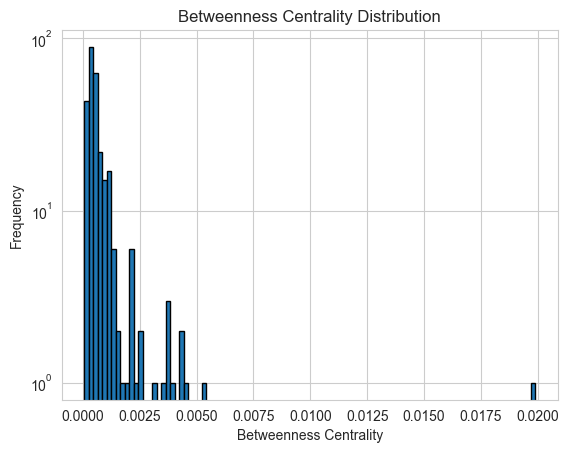

In [20]:
import matplotlib.pyplot as plt

plt.hist(mapped_genes['mean_centrality'], bins=100, edgecolor='black')
plt.title("Betweenness Centrality Distribution")
plt.xlabel("Betweenness Centrality")
plt.ylabel("Frequency")
plt.yscale("log")  # Use log scale since the distribution is often heavy-tailed
plt.show()


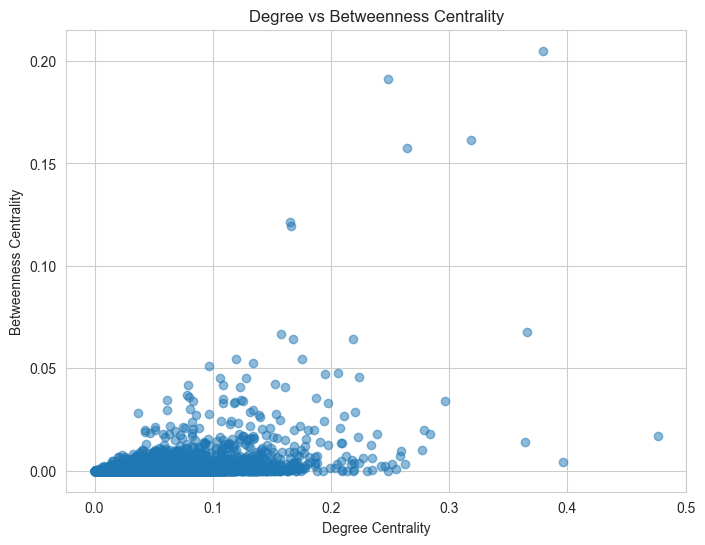

In [22]:
degree = nk.centrality.DegreeCentrality(G, normalized=True)
degree.run()
degree_scores = degree.scores()

# Scatter plot: Degree vs Betweenness
plt.figure(figsize=(8, 6))
plt.scatter(degree_scores, centrality_dict.values(), alpha=0.5)
plt.title("Degree vs Betweenness Centrality")
plt.xlabel("Degree Centrality")
plt.ylabel("Betweenness Centrality")
plt.grid(True)
plt.show()


In [23]:
degree_dict = {id_to_protein[i]: score for i, score in enumerate(degree_scores)}

top_betweenness = sorted(centrality_dict.items(), key=lambda x: -x[1])[:10]
top_degree = sorted(degree_dict.items(), key=lambda x: -x[1])[:10]

print("Top 10 Proteins by Betweenness:")
for p, s in top_betweenness:
    print(f"{p}\t{s:.6f}")

print("\nTop 10 Proteins by Degree:")
for p, s in top_degree:
    print(f"{p}\t{s:.6f}")


Top 10 Proteins by Betweenness:
9606.ENSP00000269305	0.205039
9606.ENSP00000362680	0.191442
9606.ENSP00000495360	0.161261
9606.ENSP00000335153	0.157330
9606.ENSP00000258149	0.121659
9606.ENSP00000263253	0.119327
9606.ENSP00000451828	0.067519
9606.ENSP00000418960	0.066547
9606.ENSP00000405330	0.064526
9606.ENSP00000441543	0.064481

Top 10 Proteins by Degree:
9606.ENSP00000380070	0.476863
9606.ENSP00000494750	0.396137
9606.ENSP00000269305	0.379319
9606.ENSP00000451828	0.365865
9606.ENSP00000478887	0.364234
9606.ENSP00000495360	0.318673
9606.ENSP00000275493	0.296606
9606.ENSP00000380432	0.283610
9606.ENSP00000295897	0.279024
9606.ENSP00000360266	0.277189
